In [2]:
# === Cell 1: imports + загрузка артефактов ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')

ARTIFACTS = Path('data') / 'artifacts'

# Данные
train_df = pd.read_parquet(ARTIFACTS / 'train.parquet')
test_df  = pd.read_parquet(ARTIFACTS / 'test.parquet')

# Модели
gbm_demand = joblib.load(ARTIFACTS / 'gbm_demand.pkl')
cf_dml     = joblib.load(ARTIFACTS / 'cf_dml.pkl')

print(f'Train: {train_df.shape}')
print(f'Test : {test_df.shape}')
print(f'GBM model loaded, CausalForest loaded.')

# Effect modifiers — те же, что использовали при обучении cf_dml
EFFECT_MODIFIERS = ['manuf_code', 'subcat_code', 'seg_code', 'size_oz']

/Users/miziulin_e/Projects/UNI/demo-prices/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train: (150672, 40)
Test : (19004, 40)
GBM model loaded, CausalForest loaded.


In [3]:
# === Cell 2: симуляция себестоимости ===

# Берём BASE_PRICE как референс для cost (cost не меняется при промо)
# Для каждого SKU считаем медиану BASE_PRICE — это устойчивая оценка "обычной" цены
sku_base_price = (
    train_df.groupby('UPC')['BASE_PRICE']
    .median()
    .reset_index()
    .rename(columns={'BASE_PRICE': 'sku_base_price'})
)

# Маржа по типу бренда: PL — 40%, бренды — 30%
def margin_by_manuf(manuf):
    return 0.40 if manuf == 'PRIVATE LABEL' else 0.30

sku_info = (
    train_df[['UPC', 'DESCRIPTION', 'MANUFACTURER', 'SUB_CATEGORY', 'size_oz']]
    .drop_duplicates(subset='UPC')
    .merge(sku_base_price, on='UPC')
)
sku_info['gross_margin'] = sku_info['MANUFACTURER'].apply(margin_by_manuf)
sku_info['cost'] = sku_info['sku_base_price'] * (1 - sku_info['gross_margin'])

# Также сохраним исторический диапазон цены для каждого SKU — пригодится для bounds
sku_price_range = train_df.groupby('UPC')['PRICE'].agg(['min', 'max', 'mean']).reset_index()
sku_price_range.columns = ['UPC', 'price_min_hist', 'price_max_hist', 'price_mean_hist']
sku_info = sku_info.merge(sku_price_range, on='UPC')

print('=== SKU costs table ===')
print(sku_info[['DESCRIPTION', 'MANUFACTURER', 'sku_base_price', 'cost',
                'gross_margin', 'price_min_hist', 'price_max_hist']]
      .to_string(index=False))

# Сохраним для будущих ячеек
sku_info.to_parquet(ARTIFACTS / 'sku_info.parquet', index=False)

=== SKU costs table ===
              DESCRIPTION  MANUFACTURER  sku_base_price  cost  gross_margin  price_min_hist  price_max_hist
 PL HONEY NUT TOASTD OATS PRIVATE LABEL            1.84 1.104           0.4            1.07            1.99
           PL RAISIN BRAN PRIVATE LABEL            1.83 1.098           0.4            1.10            2.00
  PL BT SZ FRSTD SHRD WHT PRIVATE LABEL            2.31 1.386           0.4            1.03            2.49
    GM HONEY NUT CHEERIOS    GENERAL MI            2.95 2.065           0.3            1.50            3.39
              GM CHEERIOS    GENERAL MI            4.39 3.073           0.3            1.50            5.19
              GM CHEERIOS    GENERAL MI            3.17 2.219           0.3            0.58            3.56
       QKER LIFE ORIGINAL        QUAKER            2.92 2.044           0.3            0.91            4.42
QKER CAP N CRUNCH BERRIES        QUAKER            2.59 1.813           0.3            1.06            3.09
    

In [5]:
# === Cell 3 (fixed): векторизованная функция предсказания спроса ===

def predict_demand_at_price(rows_df, candidate_prices,
                             cf_dml=cf_dml, gbm_demand=gbm_demand):
    """
    Векторизованное предсказание спроса.

    rows_df          : DataFrame с N строками контекста
    candidate_prices : скаляр или array длиной N — кандидат-цены

    Возвращает dict с массивами длиной N:
      units_predicted, units_baseline, price_baseline, theta
    """
    feature_cols = gbm_demand.feature_name_

    # Baseline-спрос при исторических ценах — берём сразу для всех строк
    X = rows_df[feature_cols]  # сохраняет dtypes (DataFrame slicing, не Series)
    log_units_baseline = gbm_demand.predict(X)
    units_baseline = np.exp(log_units_baseline)
    price_baseline = rows_df['PRICE'].values

    # Локальная эластичность для каждой строки
    em = rows_df[EFFECT_MODIFIERS].values
    theta = cf_dml.effect(em)

    # Constant-elasticity demand
    candidate_prices = np.atleast_1d(candidate_prices).astype(float)
    if len(candidate_prices) == 1:
        candidate_prices = np.full(len(rows_df), candidate_prices[0])

    units_at_candidate = units_baseline * (candidate_prices / price_baseline) ** theta

    return {
        'units_predicted': units_at_candidate,
        'units_baseline':  units_baseline,
        'price_baseline':  price_baseline,
        'theta':           theta,
    }

# Проверим на одной строке
sample = test_df.sample(1, random_state=42)
sample_row = sample.iloc[0]
print(f'Sample: {sample_row["DESCRIPTION"]}, store {sample_row["STORE_NUM"]}, '
      f'week {sample_row["WEEK_END_DATE"].date()}')
print(f'Historical PRICE = ${sample_row["PRICE"]:.2f}, actual UNITS = {sample_row["UNITS"]}')

# Кривая спроса для этого контекста
print('\nDemand curve:')
for p in [1.5, 2.0, 2.5, 3.0, 3.5, 4.0]:
    res = predict_demand_at_price(sample, candidate_prices=p)
    print(f'  price ${p:.2f}: units = {res["units_predicted"][0]:.1f}  '
          f'(θ = {res["theta"][0]:+.2f})')

# И сразу проверим batch-режим — на 5 строках по их историческим ценам
sample_batch = test_df.sample(5, random_state=42)
res_batch = predict_demand_at_price(sample_batch, sample_batch['PRICE'].values)
print('\nBatch mode sanity check (predict at historical prices):')
print(pd.DataFrame({
    'DESCRIPTION'    : sample_batch['DESCRIPTION'].values,
    'price_hist'     : sample_batch['PRICE'].values,
    'units_actual'   : sample_batch['UNITS'].values,
    'units_predicted': res_batch['units_predicted'],
    'theta'          : res_batch['theta'],
}).to_string(index=False))

Sample: POST HNY BN OTS HNY RSTD, store 2281, week 2011-11-09
Historical PRICE = $3.54, actual UNITS = 19

Demand curve:
  price $1.50: units = 362.3  (θ = -2.54)
  price $2.00: units = 174.6  (θ = -2.54)
  price $2.50: units = 99.2  (θ = -2.54)
  price $3.00: units = 62.4  (θ = -2.54)
  price $3.50: units = 42.2  (θ = -2.54)
  price $4.00: units = 30.1  (θ = -2.54)

Batch mode sanity check (predict at historical prices):
              DESCRIPTION  price_hist  units_actual  units_predicted     theta
 POST HNY BN OTS HNY RSTD        3.54            19        41.036402 -2.536552
    GM HONEY NUT CHEERIOS        2.94           100        82.193194 -2.570085
POST FM SZ HNYBNCH OT ALM        3.31            54        22.689061 -1.797643
 PL HONEY NUT TOASTD OATS        1.60            15        12.508999 -2.086235
  PL BT SZ FRSTD SHRD WHT        2.21            10        11.471565 -2.068573


Sample: PL RAISIN BRAN, store 623
Historical PRICE = $1.82, cost = $1.10

Historical:  price = $1.82, units = 31, profit = $22.38
Optimal   :  price = $1.93, units = 18.7, profit = $15.59
Uplift    :  -30.3% vs historical


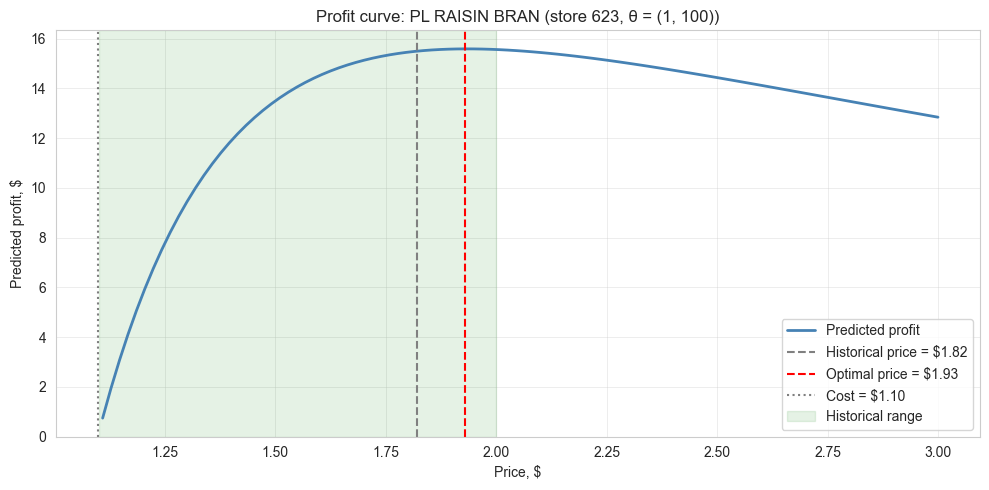

In [6]:
# === Cell 4: profit function + grid-search optimizer ===

# Merge cost в датафреймы — он нужен для расчёта прибыли
train_df = train_df.merge(sku_info[['UPC', 'cost']], on='UPC', how='left')
test_df  = test_df.merge(sku_info[['UPC', 'cost']],  on='UPC', how='left')

def profit_at_price(rows_df, candidate_prices, cf_dml=cf_dml, gbm_demand=gbm_demand):
    """Прибыль = (price - cost) * units. Векторизованно."""
    demand = predict_demand_at_price(rows_df, candidate_prices, cf_dml, gbm_demand)

    candidate_prices = np.atleast_1d(candidate_prices).astype(float)
    if len(candidate_prices) == 1:
        candidate_prices = np.full(len(rows_df), candidate_prices[0])

    costs = rows_df['cost'].values
    profits = (candidate_prices - costs) * demand['units_predicted']

    return {
        'profit':          profits,
        'price':           candidate_prices,
        'units_predicted': demand['units_predicted'],
        'cost':            costs,
        'margin':          candidate_prices - costs,
    }


def optimize_price_grid(rows_df, price_grid, cf_dml=cf_dml, gbm_demand=gbm_demand):
    """
    Для каждой строки выбирает цену из price_grid, максимизирующую прибыль.

    price_grid : array длиной K — кандидат-цены для перебора
    rows_df    : DataFrame с N строками контекста

    Возвращает массивы длиной N с оптимальной ценой, прибылью, спросом для каждой строки.
    """
    N = len(rows_df)
    K = len(price_grid)

    # Матрица прибыли [N x K]: для каждой строки — прибыль при каждой цене из сетки
    profit_matrix = np.zeros((N, K))
    units_matrix  = np.zeros((N, K))

    for k, price in enumerate(price_grid):
        res = profit_at_price(rows_df, candidate_prices=price)
        profit_matrix[:, k] = res['profit']
        units_matrix[:, k]  = res['units_predicted']

    # Для каждой строки — индекс лучшей цены
    best_idx    = profit_matrix.argmax(axis=1)
    best_price  = price_grid[best_idx]
    best_profit = profit_matrix[np.arange(N), best_idx]
    best_units  = units_matrix[np.arange(N), best_idx]

    return {
        'optimal_price':  best_price,
        'optimal_profit': best_profit,
        'optimal_units':  best_units,
        'profit_matrix':  profit_matrix,  # для отладки и графиков
        'price_grid':     price_grid,
    }


# Демо на одной строке — построим график profit vs price
sample_row_df = test_df.iloc[[1000]].copy()  # одна строка как DataFrame
print(f'Sample: {sample_row_df["DESCRIPTION"].iloc[0]}, store {sample_row_df["STORE_NUM"].iloc[0]}')
print(f'Historical PRICE = ${sample_row_df["PRICE"].iloc[0]:.2f}, cost = ${sample_row_df["cost"].iloc[0]:.2f}')

# Сетка цен — широкий диапазон от cost до 2x исторического максимума
upc = sample_row_df['UPC'].iloc[0]
price_min_hist = sku_info.loc[sku_info['UPC'] == upc, 'price_min_hist'].iloc[0]
price_max_hist = sku_info.loc[sku_info['UPC'] == upc, 'price_max_hist'].iloc[0]
cost = sample_row_df['cost'].iloc[0]

price_grid = np.linspace(cost * 1.01, price_max_hist * 1.5, 100)
opt = optimize_price_grid(sample_row_df, price_grid)

# Историческая прибыль для сравнения
hist_price = sample_row_df['PRICE'].iloc[0]
hist_units = sample_row_df['UNITS'].iloc[0]
hist_profit = (hist_price - cost) * hist_units

print(f'\nHistorical:  price = ${hist_price:.2f}, units = {hist_units}, profit = ${hist_profit:.2f}')
print(f'Optimal   :  price = ${opt["optimal_price"][0]:.2f}, '
      f'units = {opt["optimal_units"][0]:.1f}, profit = ${opt["optimal_profit"][0]:.2f}')
print(f'Uplift    :  {(opt["optimal_profit"][0] / hist_profit - 1) * 100:+.1f}% vs historical')

# Визуализация profit curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(price_grid, opt['profit_matrix'][0], color='steelblue', linewidth=2, label='Predicted profit')
ax.axvline(hist_price, color='gray', linestyle='--', label=f'Historical price = ${hist_price:.2f}')
ax.axvline(opt['optimal_price'][0], color='red', linestyle='--',
           label=f'Optimal price = ${opt["optimal_price"][0]:.2f}')
ax.axvline(cost, color='black', linestyle=':', alpha=0.5, label=f'Cost = ${cost:.2f}')
ax.axvspan(price_min_hist, price_max_hist, alpha=0.1, color='green', label='Historical range')
ax.set_xlabel('Price, $')
ax.set_ylabel('Predicted profit, $')
ax.set_title(f'Profit curve: {sample_row_df["DESCRIPTION"].iloc[0]} '
             f'(store {sample_row_df["STORE_NUM"].iloc[0]}, θ = {opt["profit_matrix"].shape})')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# === Cell 4b (fix): честный uplift — model-based baseline ===

# Историческая прибыль НА ОСНОВЕ ПРОГНОЗА (а не фактических UNITS)
hist_demand = predict_demand_at_price(sample_row_df, sample_row_df['PRICE'].values)
hist_units_predicted = hist_demand['units_predicted'][0]
hist_profit_model = (hist_price - cost) * hist_units_predicted

print(f'Historical (actual)    : price = ${hist_price:.2f}, units_actual = {hist_units}, '
      f'profit = ${hist_profit:.2f}')
print(f'Historical (model-based): price = ${hist_price:.2f}, units_pred = {hist_units_predicted:.1f}, '
      f'profit = ${hist_profit_model:.2f}')
print(f'Optimal (model-based)  : price = ${opt["optimal_price"][0]:.2f}, '
      f'units_pred = {opt["optimal_units"][0]:.1f}, profit = ${opt["optimal_profit"][0]:.2f}')

uplift_model = (opt['optimal_profit'][0] / hist_profit_model - 1) * 100
print(f'\nModel-based uplift     : {uplift_model:+.1f}%')
print(f'(Это и есть честная метрика — насколько лучше можно играть по правилам модели)')

Historical (actual)    : price = $1.82, units_actual = 31, profit = $22.38
Historical (model-based): price = $1.82, units_pred = 21.5, profit = $15.50
Optimal (model-based)  : price = $1.93, units_pred = 18.7, profit = $15.59

Model-based uplift     : +0.6%
(Это и есть честная метрика — насколько лучше можно играть по правилам модели)


In [9]:
# === Cell 5 (fast): векторизованный оптимизатор ===

# Параметры ограничений
MIN_MARGIN          = 0.15
HIST_LOWER_PADDING  = 0.95
HIST_UPPER_PADDING  = 1.05
MAX_CHANGE_PCT      = 0.30
N_GRID              = 60

def optimize_test_set_fast(rows_df, sku_info):
    """
    Векторизованный оптимизатор. Для каждой строки:
    1) Считает baseline_units = GBM(row) ОДИН раз
    2) Считает theta = CATE(row) ОДИН раз
    3) Применяет аналитическую формулу прибыли на всей сетке цен
    """
    N = len(rows_df)

    # === Шаг 1: один раз посчитать baseline_units и theta для всех строк ===
    feature_cols = gbm_demand.feature_name_
    log_units_baseline = gbm_demand.predict(rows_df[feature_cols])
    units_baseline = np.exp(log_units_baseline)

    theta = cf_dml.effect(rows_df[EFFECT_MODIFIERS].values)

    price_baseline = rows_df['PRICE'].values
    costs = rows_df['cost'].values

    # === Шаг 2: построить bounds для каждой строки ===
    sku_info_indexed = sku_info.set_index('UPC')
    price_min_hist = sku_info_indexed.loc[rows_df['UPC'].values, 'price_min_hist'].values
    price_max_hist = sku_info_indexed.loc[rows_df['UPC'].values, 'price_max_hist'].values

    lower = np.maximum.reduce([
        costs * (1 + MIN_MARGIN),
        price_min_hist * HIST_LOWER_PADDING,
        price_baseline * (1 - MAX_CHANGE_PCT),
    ])
    upper = np.minimum.reduce([
        price_max_hist * HIST_UPPER_PADDING,
        price_baseline * (1 + MAX_CHANGE_PCT),
    ])

    # Защита от инвертированных bounds
    invalid = lower >= upper

    # === Шаг 3: сетка цен для каждой строки ===
    # price_grid[i, k] = цена k-го кандидата для i-й строки
    alphas = np.linspace(0, 1, N_GRID).reshape(1, -1)        # [1 x K]
    price_grid = lower.reshape(-1, 1) + alphas * (upper - lower).reshape(-1, 1)  # [N x K]

    # === Шаг 4: спрос и прибыль на всей сетке — ВЕКТОРИЗОВАННО ===
    # units(P) = units_baseline * (P / P_baseline) ^ theta
    ratio = price_grid / price_baseline.reshape(-1, 1)        # [N x K]
    units_matrix = units_baseline.reshape(-1, 1) * ratio ** theta.reshape(-1, 1)  # [N x K]
    profit_matrix = (price_grid - costs.reshape(-1, 1)) * units_matrix             # [N x K]

    # === Шаг 5: argmax по сетке для каждой строки ===
    best_k = profit_matrix.argmax(axis=1)
    optimal_price  = price_grid[np.arange(N), best_k]
    optimal_units  = units_matrix[np.arange(N), best_k]
    optimal_profit = profit_matrix[np.arange(N), best_k]

    # Если bounds инвалидные — возвращаем текущую цену
    optimal_price[invalid]  = price_baseline[invalid]
    optimal_units[invalid]  = units_baseline[invalid]
    optimal_profit[invalid] = (price_baseline[invalid] - costs[invalid]) * units_baseline[invalid]

    return pd.DataFrame({
        'optimal_price'       : optimal_price,
        'optimal_units_pred'  : optimal_units,
        'optimal_profit_model': optimal_profit,
        'price_min_allowed'   : lower,
        'price_max_allowed'   : upper,
        'units_baseline'      : units_baseline,
        'theta'               : theta,
        'constrained_invalid' : invalid,
    }, index=rows_df.index)


print('Optimizing test set (быстрая версия)...')
import time
t0 = time.time()
opt_results = optimize_test_set_fast(test_df, sku_info)
print(f'Done in {time.time() - t0:.1f}s.')

# Merge с test_df
test_opt = test_df.join(opt_results, how='left')

# Historical profit by model (для честного uplift)
test_opt['hist_profit_model'] = (test_df['PRICE'] - test_df['cost']) * test_opt['units_baseline']

# Uplift
test_opt['uplift_abs']       = test_opt['optimal_profit_model'] - test_opt['hist_profit_model']
test_opt['uplift_pct']       = test_opt['uplift_abs'] / test_opt['hist_profit_model'] * 100
test_opt['price_change_pct'] = (test_opt['optimal_price'] - test_opt['PRICE']) / test_opt['PRICE'] * 100

print('\n=== Aggregate results ===')
print(f'Total rows                     : {len(test_opt)}')
print(f'Total historical profit (model): ${test_opt["hist_profit_model"].sum():,.0f}')
print(f'Total optimal profit (model)   : ${test_opt["optimal_profit_model"].sum():,.0f}')
print(f'Total uplift (absolute)        : ${test_opt["uplift_abs"].sum():,.0f}')
total_uplift_pct = test_opt["uplift_abs"].sum() / test_opt["hist_profit_model"].sum() * 100
print(f'Total uplift (percentage)      : {total_uplift_pct:+.2f}%')

print(f'\n=== Per-row distribution ===')
print(f'Median uplift per row : {test_opt["uplift_pct"].median():+.2f}%')
print(f'Mean uplift per row   : {test_opt["uplift_pct"].mean():+.2f}%')
print(f'p25 / p75             : {test_opt["uplift_pct"].quantile(0.25):+.2f}% / {test_opt["uplift_pct"].quantile(0.75):+.2f}%')

print(f'\n=== Price changes ===')
print(f'Mean price change      : {test_opt["price_change_pct"].mean():+.2f}%')
print(f'Median price change    : {test_opt["price_change_pct"].median():+.2f}%')
print(f'Rows with price UP     : {(test_opt["price_change_pct"] > 1).sum()} ({(test_opt["price_change_pct"] > 1).mean()*100:.1f}%)')
print(f'Rows with price DOWN   : {(test_opt["price_change_pct"] < -1).sum()} ({(test_opt["price_change_pct"] < -1).mean()*100:.1f}%)')
print(f'Rows unchanged         : {(test_opt["price_change_pct"].abs() <= 1).sum()}')

Optimizing test set (быстрая версия)...
Done in 0.2s.

=== Aggregate results ===
Total rows                     : 19004
Total historical profit (model): $435,335
Total optimal profit (model)   : $534,423
Total uplift (absolute)        : $99,089
Total uplift (percentage)      : +22.76%

=== Per-row distribution ===
Median uplift per row : +4.64%
Mean uplift per row   : +19.69%
p25 / p75             : +0.94% / +20.42%

=== Price changes ===
Mean price change      : +11.87%
Median price change    : +13.33%
Rows with price UP     : 14062 (74.0%)
Rows with price DOWN   : 4437 (23.3%)
Rows unchanged         : 505
